In [1]:
import pandas as pd
import numpy as np


In [5]:
# Data visualization
import matplotlib.pyplot as plt
import seaborn as sns

In [6]:
df=pd.read_csv("Train.csv")
df.head()

,ID,Warehouse_block,Mode_of_Shipment,Customer_care_calls,Customer_rating,Cost_of_the_Product,Prior_purchases,Product_importance,Gender,Discount_offered,Weight_in_gms,Reached.on.Time_Y.N
0,1,D,Flight,4,2,177,3,low,F,44,1233,1
1,2,F,Flight,4,5,216,2,low,M,59,3088,1
2,3,A,Flight,2,2,183,4,low,M,48,3374,1
3,4,B,Flight,3,3,176,4,medium,M,10,1177,1
4,5,C,Flight,2,2,184,3,medium,F,46,2484,1


### Frequency Table

In [22]:
df['Mode_of_Shipment'].value_counts()
df['Mode_of_Shipment'].value_counts(normalize=True) * 100   # percentage


Mode_of_Shipment
Ship      67.842531
Flight    16.156014
Road      16.001455
Name: proportion, dtype: float64

## Bar Plot
Best for categorical variables. Shows counts directly.

C:\Users\Ramu\AppData\Local\Temp\ipykernel_8416\1582823898.py:1: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(x='Mode_of_Shipment', data=df, palette="Set2")


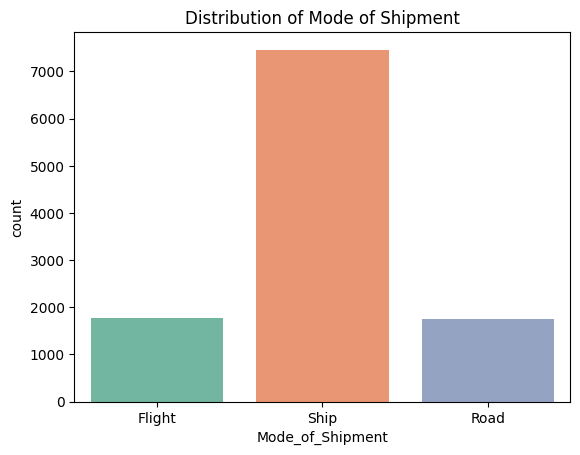

In [23]:
sns.countplot(x='Mode_of_Shipment', data=df, palette="Set2")
plt.title("Distribution of Mode of Shipment")
plt.show()


### Pie Chart
Good for showing percentage share (but avoid if many categories).

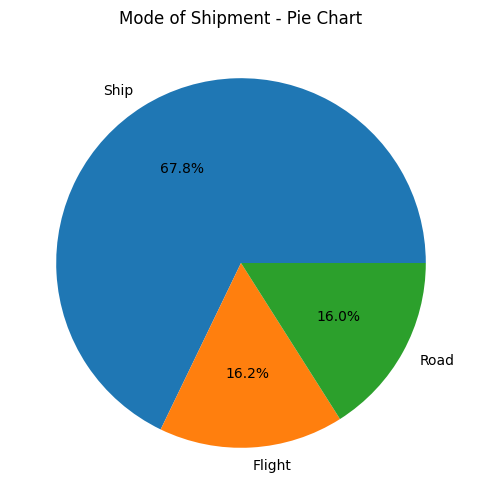

In [24]:
df['Mode_of_Shipment'].value_counts().plot.pie(autopct="%1.1f%%", figsize=(6,6))
plt.title("Mode of Shipment - Pie Chart")
plt.ylabel("")
plt.show()


###  Histogram
Shows distribution (normal, skewed, uniform, etc.).

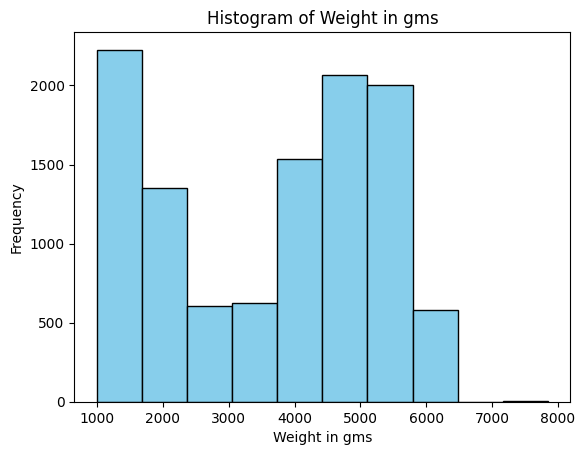

In [ ]:
plt.hist(df['Weight_in_gms'], bins=10, color='skyblue', edgecolor='black')
plt.title("Histogram of Weight in gms")
plt.xlabel("Weight in gms")
plt.ylabel("Frequency")
plt.show()

### KDE Plot (Probability Distribution)
Smooth curve, shows probability density. Useful for continuous variables.

C:\Users\Ramu\AppData\Local\Temp\ipykernel_8416\4180920438.py:1: FutureWarning: 

`shade` is now deprecated in favor of `fill`; setting `fill=True`.
This will become an error in seaborn v0.14.0; please update your code.

  sns.kdeplot(df['Weight_in_gms'], shade=True, color="blue")


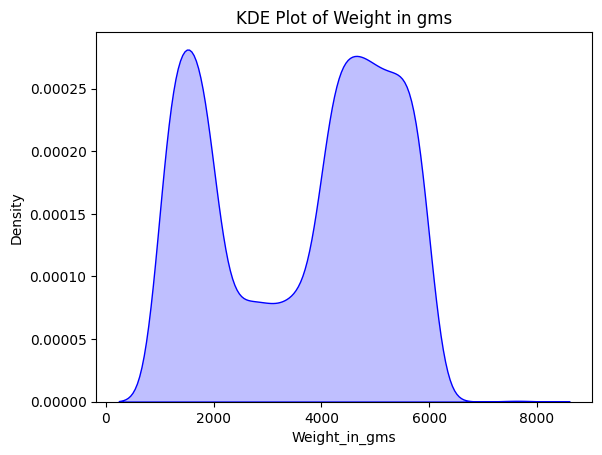

In [27]:
sns.kdeplot(df['Weight_in_gms'], shade=True, color="blue")
plt.title("KDE Plot of Weight in gms")
plt.show()


### Boxplot
Detects outliers, spread, median, quartiles.

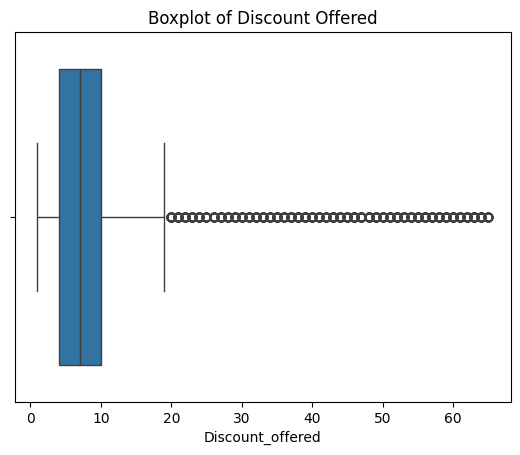

In [28]:
sns.boxplot(x=df['Discount_offered'])
plt.title("Boxplot of Discount Offered")
plt.show()


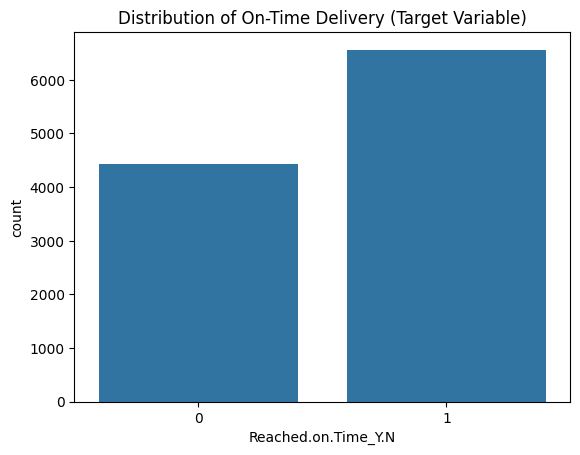

Reached.on.Time_Y.N
1    59.669061
0    40.330939
Name: proportion, dtype: float64

In [ ]:
sns.countplot(x='Reached.on.Time_Y.N', data=df)
plt.title("Distribution of On-Time Delivery (Target Variable)")
plt.show()
df['Reached.on.Time_Y.N'].value_counts(normalize=True)*100


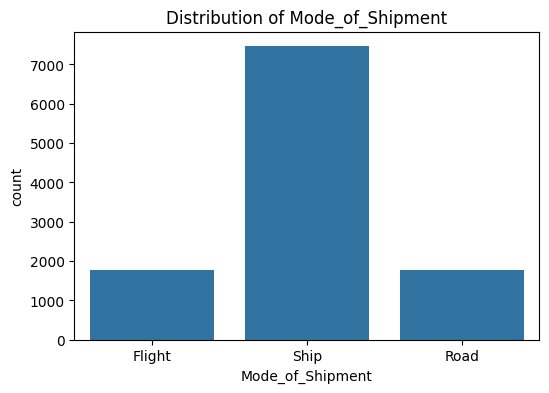

Mode_of_Shipment
Ship      67.842531
Flight    16.156014
Road      16.001455
Name: proportion, dtype: float64


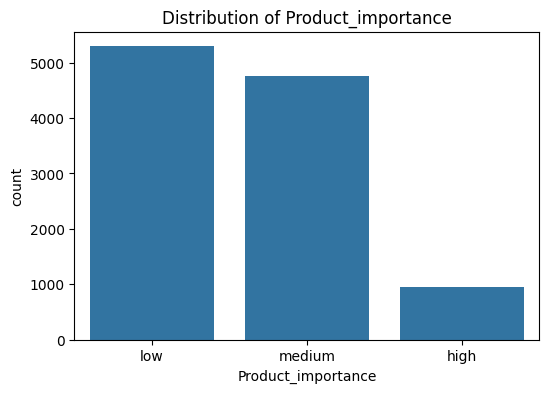

Product_importance
low       48.158924
medium    43.222111
high       8.618965
Name: proportion, dtype: float64


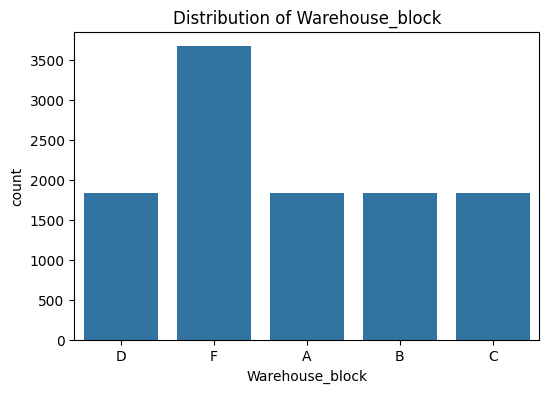

Warehouse_block
F    33.330303
D    16.674243
A    16.665151
B    16.665151
C    16.665151
Name: proportion, dtype: float64


In [8]:
for col in ['Mode_of_Shipment','Product_importance','Warehouse_block']:
    plt.figure(figsize=(6,4))
    sns.countplot(x=col, data=df)
    plt.title(f"Distribution of {col}")
    plt.show()
    print(df[col].value_counts(normalize=True)*100)


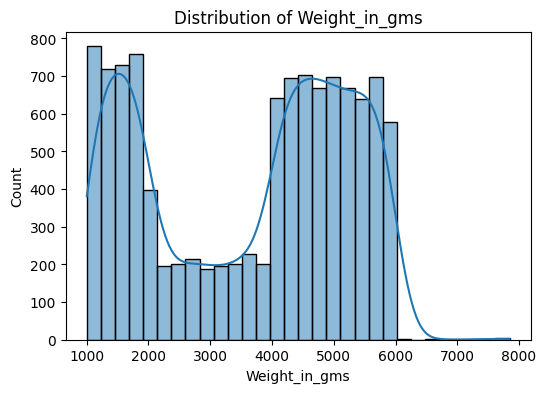

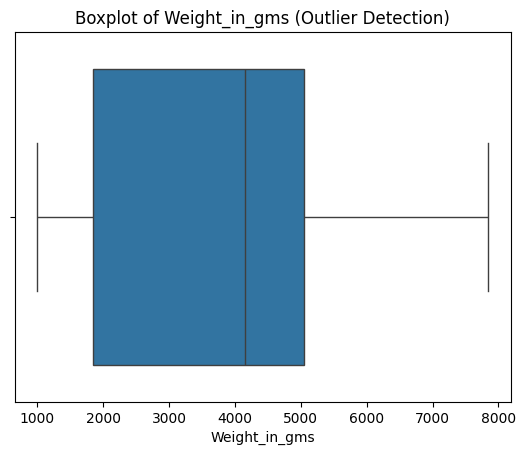

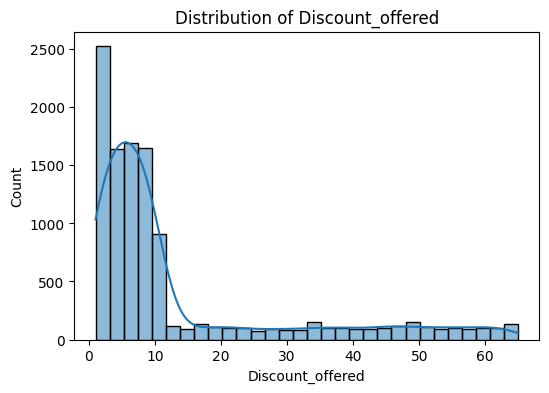

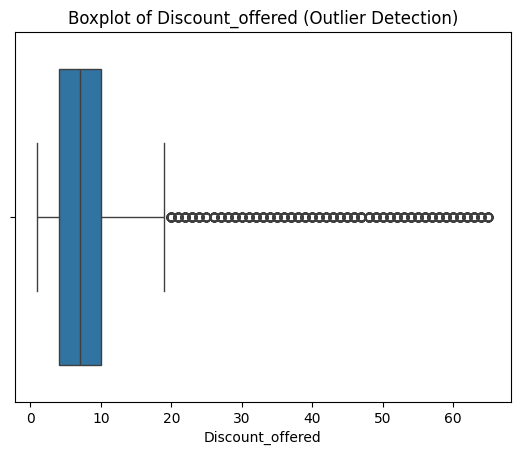

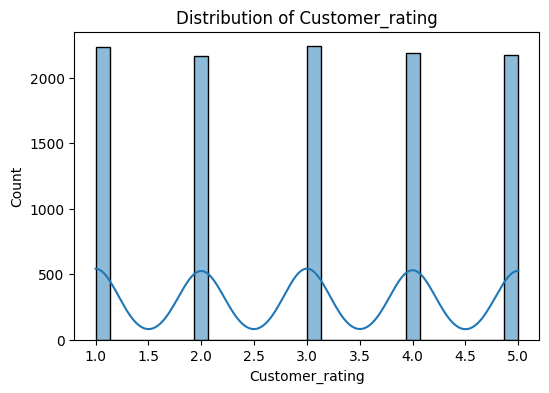

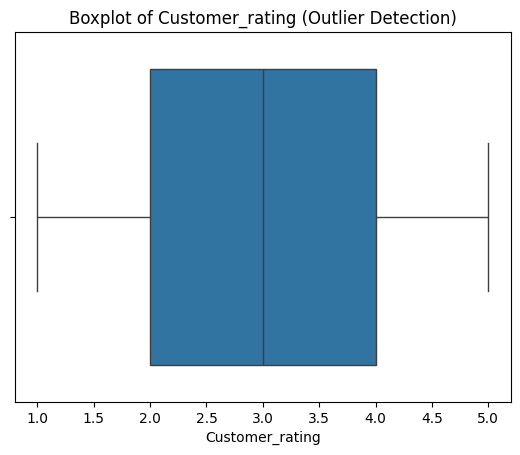

In [9]:
num_cols = ['Weight_in_gms','Discount_offered','Customer_rating']

for col in num_cols:
    plt.figure(figsize=(6,4))
    sns.histplot(df[col], kde=True, bins=30)
    plt.title(f"Distribution of {col}")
    plt.show()
    
    sns.boxplot(x=df[col])
    plt.title(f"Boxplot of {col} (Outlier Detection)")
    plt.show()


### Bivariate Analysis (Two Variables)

👉 Here we study relationship between two variables.

### Categorical vs Target Variable

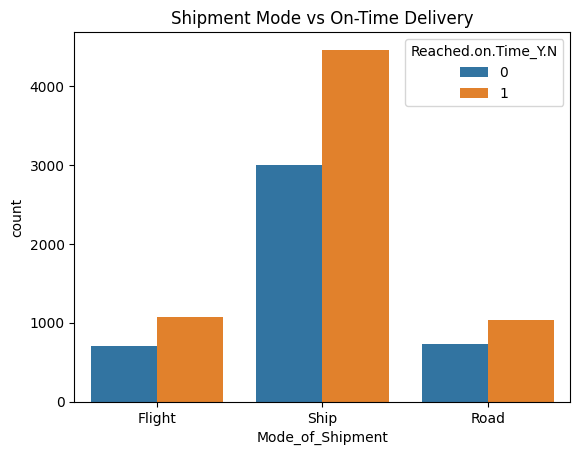

In [15]:
sns.countplot(x="Mode_of_Shipment", hue="Reached.on.Time_Y.N", data=df)
plt.title("Shipment Mode vs On-Time Delivery")
plt.show()



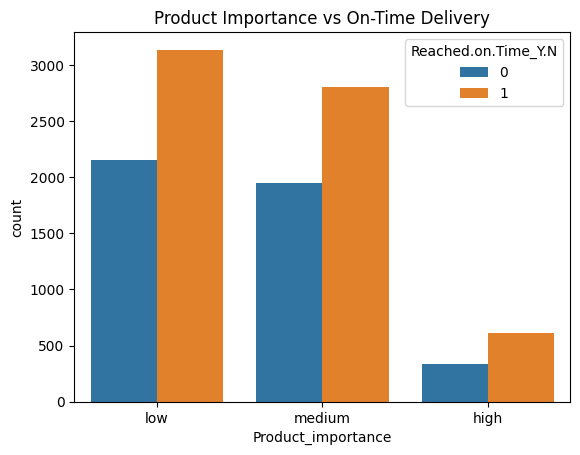

In [16]:
sns.countplot(x="Product_importance", hue="Reached.on.Time_Y.N", data=df)
plt.title("Product Importance vs On-Time Delivery")
plt.show()

## Crosstab / Contingency Table
Shows percentage distribution of on-time/delayed deliveries for each shipment mode.

In [29]:
pd.crosstab(df['Mode_of_Shipment'], df['Reached.on.Time_Y.N'], normalize='index')*100


Reached.on.Time_Y.N,0,1
Mode_of_Shipment,,
Flight,39.842431,60.157569
Road,41.193182,58.806818
Ship,40.243902,59.756098


## Stacked Bar Plot
Useful to visualize proportions in stacked form.

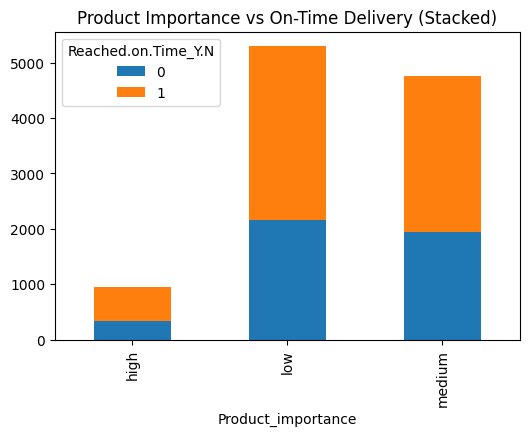

In [30]:
ct = pd.crosstab(df['Product_importance'], df['Reached.on.Time_Y.N'])
ct.plot(kind="bar", stacked=True, figsize=(6,4))
plt.title("Product Importance vs On-Time Delivery (Stacked)")
plt.show()


### Boxplot

C:\Users\Ramu\AppData\Local\Temp\ipykernel_8416\173074388.py:1: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(x="Warehouse_block", y="Weight_in_gms", data=df, palette="pastel")


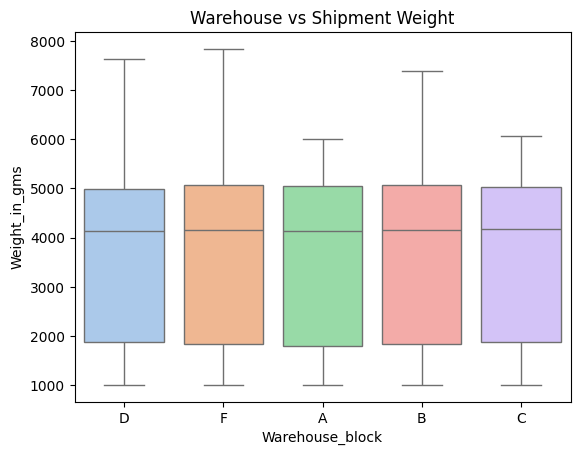

In [31]:
sns.boxplot(x="Warehouse_block", y="Weight_in_gms", data=df, palette="pastel")
plt.title("Warehouse vs Shipment Weight")
plt.show()


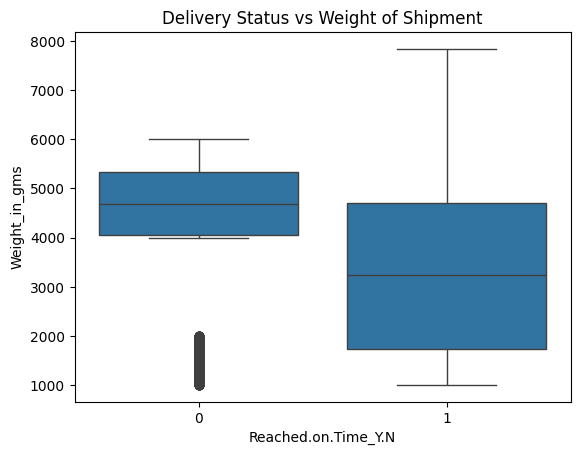

In [ ]:
sns.boxplot(x="Reached.on.Time_Y.N", y="Weight_in_gms", data=df)
plt.title("Delivery Status vs Weight of Shipment")
plt.show()


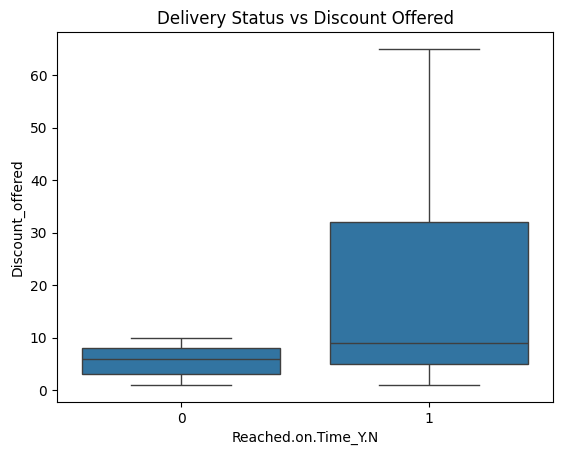

In [18]:
sns.boxplot(x="Reached.on.Time_Y.N", y="Discount_offered", data=df)
plt.title("Delivery Status vs Discount Offered")
plt.show()

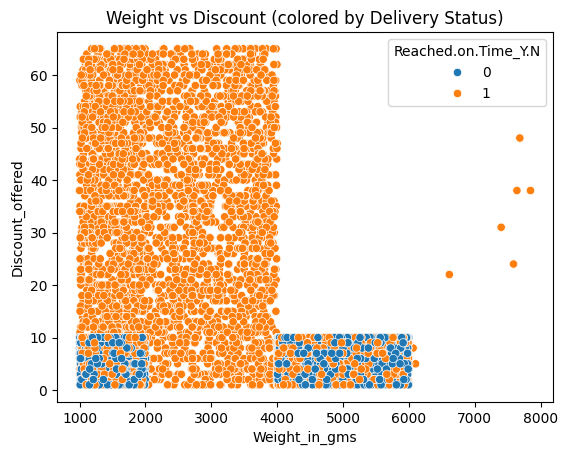

In [ ]:
sns.scatterplot(x="Weight_in_gms", y="Discount_offered", hue="Reached.on.Time_Y.N", data=df)
plt.title("Weight vs Discount (colored by Delivery Status)")
plt.show()


### Joint Plot
Shows scatter + distribution (hexbin is better for large datasets).

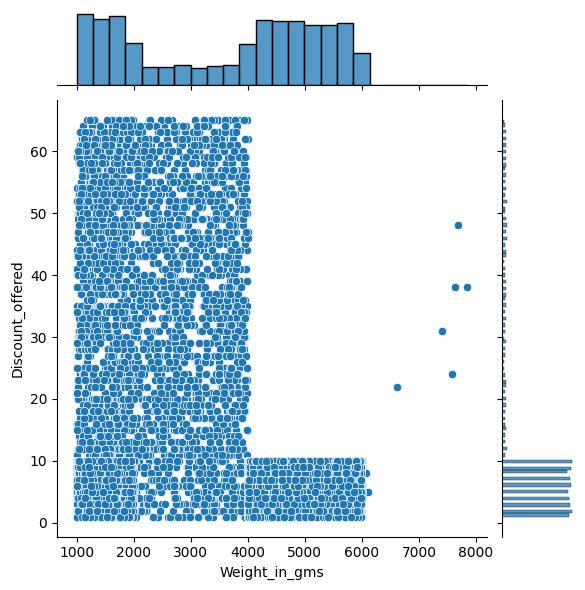

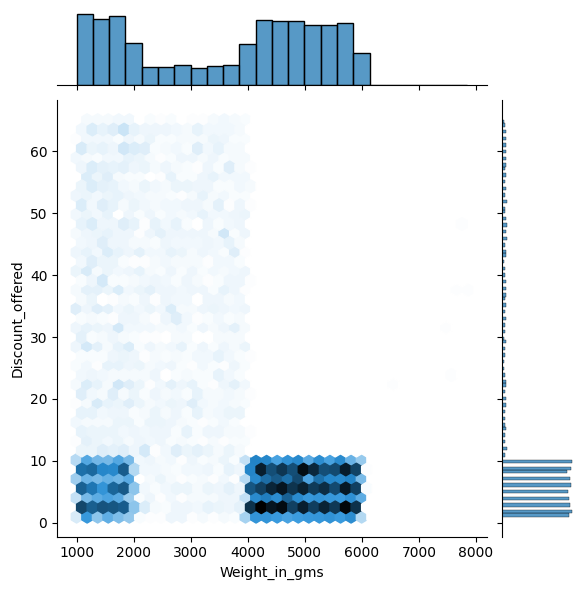

In [32]:
sns.jointplot(x="Weight_in_gms", y="Discount_offered", data=df, kind="scatter")
sns.jointplot(x="Weight_in_gms", y="Discount_offered", data=df, kind="hex")   # alternative


### Regression Plot (Trend Line)
Adds a regression line → helps see trend.

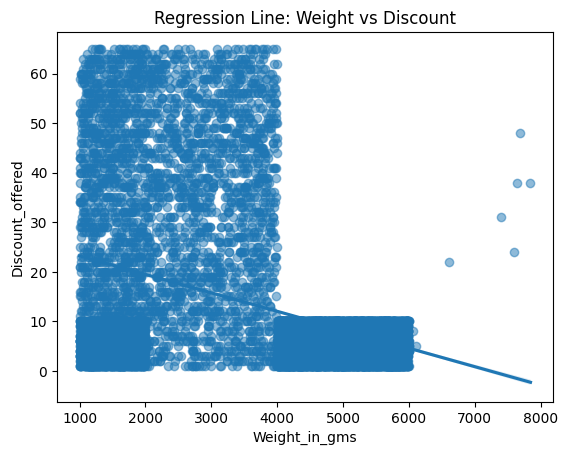

In [33]:
sns.regplot(x="Weight_in_gms", y="Discount_offered", data=df, scatter_kws={'alpha':0.5})
plt.title("Regression Line: Weight vs Discount")
plt.show()


### Correlation Heatmap
Correlation only makes sense for numerical variables because it measures linear relationships between numbers (e.g., Weight vs Discount).

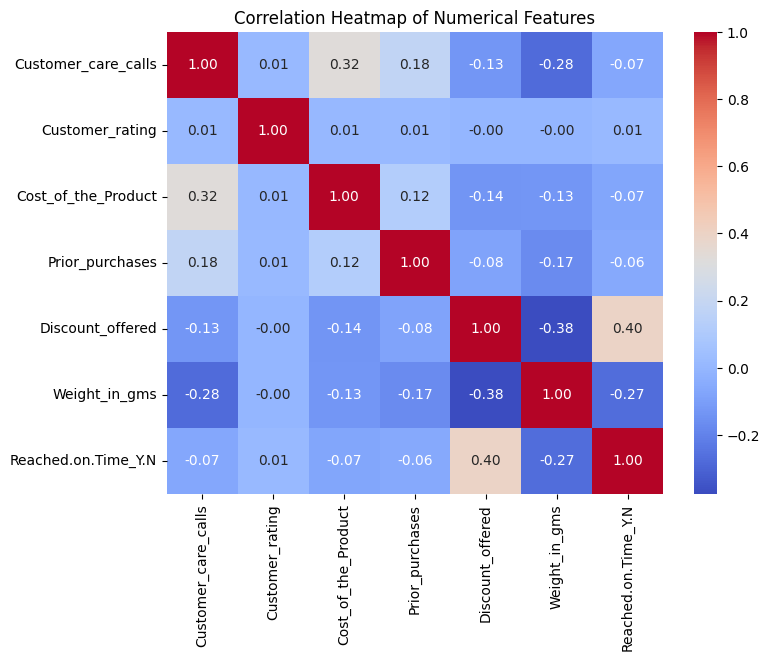

In [45]:
plt.figure(figsize=(8,6))
sns.heatmap(df[["Customer_care_calls","Customer_rating","Cost_of_the_Product","Prior_purchases","Discount_offered","Weight_in_gms","Reached.on.Time_Y.N"]].corr(), annot=True, cmap="coolwarm", fmt=".2f")
plt.title("Correlation Heatmap of Numerical Features")
plt.show()


### What to do with categorical variables then?

Instead of correlation, we use association measures:

Chi-Square Test of Independence (for categorical vs categorical)

If p < 0.05 → there is a significant association.

In [ ]:
from scipy.stats import chi2_contingency

table = pd.crosstab(df['Mode_of_Shipment'], df['Reached.on.Time_Y.N'])
chi2, p, dof, ex = chi2_contingency(table)
print("Chi-Square Test p-value:", p)

Chi-Square Test p-value: 0.6895487627593786


### Pair Plot
Gives scatterplots for all numerical variable combinations + distribution.

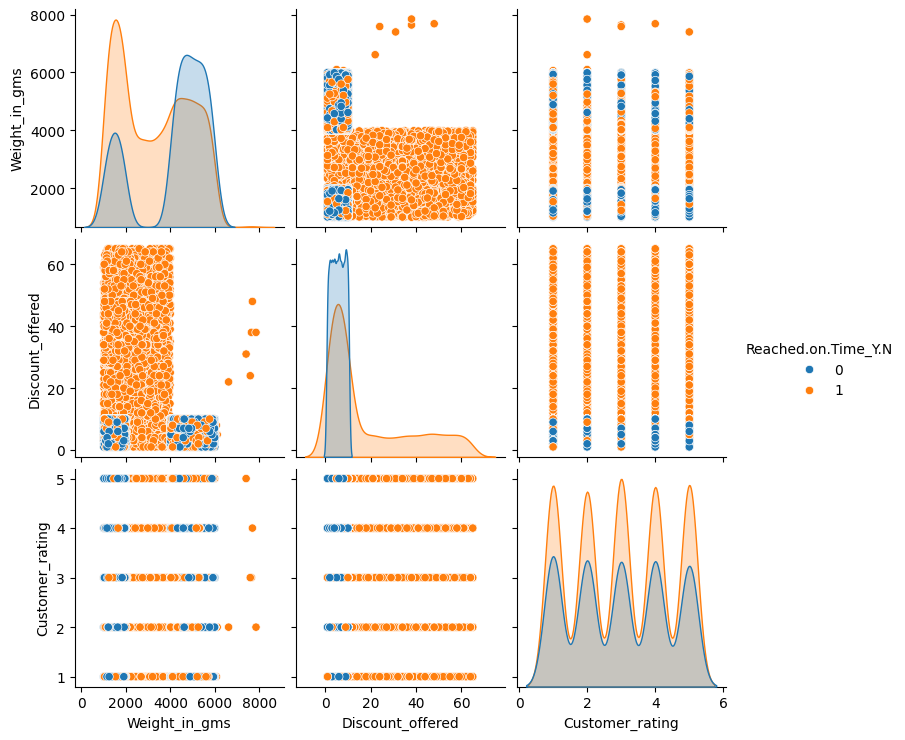

In [35]:
sns.pairplot(df[['Weight_in_gms','Discount_offered','Customer_rating','Reached.on.Time_Y.N']], hue="Reached.on.Time_Y.N")


,Customer_care_calls,Customer_rating,Cost_of_the_Product,Prior_purchases
0,4,2,177,3
1,4,5,216,2
2,2,2,183,4
3,3,3,176,4
4,2,2,184,3
...,...,...,...,...
10994,4,1,252,5
10995,4,1,232,5
10996,5,4,242,5
10997,5,2,223,6
